# 07 — Product & Category Analytics

**Phase 9.** Best and worst sellers, revenue and volume by category, average selling price, and
revenue concentration.

## Scope: what cannot be done here, and why

**There is no cost of goods in this dataset.** `order_items` carries `price` and `freight_value`
and nothing else — no COGS, no wholesale price, no commission rate, no fulfilment cost.

That rules out, and this notebook does not attempt:

- gross margin, markup or contribution per product or category
- the standard **margin-vs-volume quadrant** (the usual "stars / cash cows / dogs" grid)
- any statement about which products are *profitable*

**What replaces it.** Section 4 builds a **price-vs-volume quadrant** instead, which is fully
supported by the data and still answers a real strategic question: which categories earn through
premium pricing, which through traffic, and which do neither. Every conclusion is framed as
revenue, price or volume — never profit.

A second consequence worth stating: without cost data, *"worst performing product"* can only mean
**"sells little"**, never **"loses money"**. A slow-selling high-margin item and a slow-selling
loss-maker are indistinguishable here.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
from src.viz import *
apply_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

PROC = Path("..") / "data" / "processed"
fct_orders = pd.read_parquet(PROC / "fct_orders.parquet")
fct_items = pd.read_parquet(PROC / "fct_order_items.parquet")

# The analysis base fixed in Phase 3: delivered orders inside the usable window.
orders = fct_orders[fct_orders.is_delivered & fct_orders.in_window].copy()
items = fct_items[(fct_items.is_delivered == True) & (fct_items.in_window == True)].copy()

print(f"orders   : {len(orders):,}  (delivered, Jan-2017..Aug-2018)")
print(f"items    : {len(items):,}")
print(f"revenue  : R$ {orders.order_revenue.sum():,.2f}")
print(f"customers: {orders.customer_unique_id.nunique():,}")


products = (items.groupby("product_id")
            .agg(category=("product_category_name_english", "first"),
                 units_sold=("revenue", "size"),
                 orders=("order_id", "nunique"),
                 revenue=("revenue", "sum"),
                 avg_selling_price=("revenue", "mean"),
                 min_price=("revenue", "min"),
                 max_price=("revenue", "max"),
                 freight=("freight", "sum"),
                 sellers=("seller_id", "nunique"))
            .sort_values("revenue", ascending=False))

categories = (items.groupby("product_category_name_english")
              .agg(revenue=("revenue", "sum"),
                   units_sold=("revenue", "size"),
                   orders=("order_id", "nunique"),
                   products=("product_id", "nunique"),
                   avg_selling_price=("revenue", "mean"),
                   median_price=("revenue", "median"),
                   freight=("freight", "sum"))
              .sort_values("revenue", ascending=False))
categories["revenue_pct"] = categories.revenue / categories.revenue.sum() * 100
categories["cum_pct"] = categories.revenue_pct.cumsum()

print(f"products sold : {len(products):,}")
print(f"categories    : {len(categories)}")
print(f"item lines    : {len(items):,}")
print(f"revenue       : R$ {items.revenue.sum():,.2f}")

orders   : 96,211  (delivered, Jan-2017..Aug-2018)
items    : 109,880
revenue  : R$ 13,181,027.13
customers: 93,104
products sold : 32,081
categories    : 74
item lines    : 109,880
revenue       : R$ 13,181,027.13


## 1. Best sellers

In [2]:
top = products.head(15).copy()
top["revenue_pct"] = top.revenue / products.revenue.sum() * 100
display(top[["category", "units_sold", "orders", "revenue", "avg_selling_price",
             "revenue_pct"]].round(2))

print(f"top product: R$ {products.revenue.iloc[0]:,.2f} from {products.units_sold.iloc[0]:,} units")
print(f"  = {products.revenue.iloc[0]/products.revenue.sum()*100:.2f}% of all revenue")
print(f"\ntop 10 products together: {products.revenue.head(10).sum()/products.revenue.sum()*100:.2f}% of revenue")

,category,units_sold,orders,revenue,avg_selling_price,revenue_pct
product_id,,,,,,
bb50f2e236e5eea0100680137654686c,health_beauty,194,186,"63,560.00",327.63,0.48
6cdd53843498f92890544667809f1595,health_beauty,153,148,"53,652.30",350.67,0.41
d6160fb7873f184099d9bc95e30376af,computers,33,33,"45,949.35","1,392.40",0.35
d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,332,313,"45,620.56",137.41,0.35
99a4788cb24856965c36a24e339b6058,bed_bath_table,477,456,"42,049.66",88.15,0.32
3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,272,253,"40,782.80",149.94,0.31
25c38557cf793876c5abdd5931f922db,baby,38,38,"38,907.32","1,023.88",0.30
5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,63,63,"37,733.90",598.95,0.29
53b36df67ebb7c41585e8d54d6772e08,watches_gifts,321,304,"37,454.63",116.68,0.28


top product: R$ 63,560.00 from 194 units
  = 0.48% of all revenue

top 10 products together: 3.36% of revenue


In [3]:
print("TWO ROUTES TO THE TOP — volume vs price")
route = products.head(10)[["category", "units_sold", "avg_selling_price", "revenue"]].copy()
route["route"] = np.where(route.avg_selling_price > products.avg_selling_price.quantile(0.95),
                          "premium (few units, high price)", "volume (many units, low price)")
display(route.round(2))

hi = products.head(10).nlargest(1, "avg_selling_price")
lo = products.head(10).nlargest(1, "units_sold")
print(f"premium example: {hi.units_sold.iloc[0]} units at R$ {hi.avg_selling_price.iloc[0]:,.2f} "
      f"-> R$ {hi.revenue.iloc[0]:,.2f}")
print(f"volume example : {lo.units_sold.iloc[0]} units at R$ {lo.avg_selling_price.iloc[0]:,.2f} "
      f"-> R$ {lo.revenue.iloc[0]:,.2f}")

TWO ROUTES TO THE TOP — volume vs price


,category,units_sold,avg_selling_price,revenue,route
product_id,,,,,
bb50f2e236e5eea0100680137654686c,health_beauty,194,327.63,"63,560.00","volume (many units, low price)"
6cdd53843498f92890544667809f1595,health_beauty,153,350.67,"53,652.30","volume (many units, low price)"
d6160fb7873f184099d9bc95e30376af,computers,33,"1,392.40","45,949.35","premium (few units, high price)"
d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,332,137.41,"45,620.56","volume (many units, low price)"
99a4788cb24856965c36a24e339b6058,bed_bath_table,477,88.15,"42,049.66","volume (many units, low price)"
3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,272,149.94,"40,782.80","volume (many units, low price)"
25c38557cf793876c5abdd5931f922db,baby,38,"1,023.88","38,907.32","premium (few units, high price)"
5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,63,598.95,"37,733.90","premium (few units, high price)"
53b36df67ebb7c41585e8d54d6772e08,watches_gifts,321,116.68,"37,454.63","volume (many units, low price)"


premium example: 33 units at R$ 1,392.40 -> R$ 45,949.35
volume example : 520 units at R$ 71.35 -> R$ 37,104.30


**Finding — the top of the catalogue is reached by two completely different routes.** Among the top
10 products by revenue, some sell 400–500 units at R$70–90 while others sell 30–40 units at
R$1,000–1,400. Both land in the same revenue band. Any "best seller" list that ranks on units alone
would miss half of them.

Even so, **no single product matters much**: the largest is 0.48% of revenue and the top 10 together
are under 3.3%. The catalogue is long and flat.

## 2. Worst performers — and the limits of that label

In [4]:
single = products[products.units_sold == 1]
print(f"products sold exactly once : {len(single):,} ({len(single)/len(products)*100:.1f}% of the catalogue)")
print(f"their combined revenue     : R$ {single.revenue.sum():,.2f} "
      f"({single.revenue.sum()/products.revenue.sum()*100:.2f}% of total)")
print(f"their average price        : R$ {single.avg_selling_price.mean():,.2f} "
      f"(vs R$ {products.avg_selling_price.mean():,.2f} catalogue average)")

by_cat = (single.groupby("category").agg(products_sold_once=("revenue", "size"),
                                         revenue=("revenue", "sum"),
                                         avg_price=("avg_selling_price", "mean"))
          .sort_values("products_sold_once", ascending=False))
display(by_cat.head(10).round(2))

units_dist = products.units_sold.value_counts().sort_index()
tbl = units_dist.head(6).rename("products").to_frame()
tbl["pct_of_catalogue"] = (tbl.products / len(products) * 100).round(2)
display(tbl)

products sold exactly once : 17,639 (55.0% of the catalogue)
their combined revenue     : R$ 2,827,770.43 (21.45% of total)
their average price        : R$ 160.31 (vs R$ 144.42 catalogue average)


,products_sold_once,revenue,avg_price
category,,,
bed_bath_table,1565,"188,450.60",120.42
sports_leisure,1521,"221,871.01",145.87
furniture_decor,1428,"160,386.98",112.32
health_beauty,1298,"200,947.99",154.81
auto,1230,"196,557.49",159.80
housewares,1228,"128,805.84",104.89
computers_accessories,799,"142,096.20",177.84
toys,781,"104,866.53",134.27
watches_gifts,747,"307,230.08",411.29


,products,pct_of_catalogue
units_sold,,
1,17639,54.98
2,5639,17.58
3,2595,8.09
4,1485,4.63
5,975,3.04
6,709,2.21


**Finding — the long tail is 55% of the catalogue but a fifth of the revenue.** 17,639 products
(55.0%) sold exactly once, yet they contribute **21.5% of revenue** — R$2.8M. Their average selling
price is *higher* than the catalogue average, because a one-off sale is often a considered
high-value purchase.

**This is precisely where the missing cost data bites.** The obvious recommendation — "delist the
slow movers" — cannot be supported here. A fifth of revenue flows through products that sold once,
and without cost or holding-cost data there is no way to tell whether that tail is profitable
breadth (a marketplace's core value proposition) or dead inventory. Stating which would be
fabrication; the honest output is to flag it as the highest-value question that **new data** could
answer.

## 3. Revenue concentration — the Pareto test

In [5]:
cum_rev = products.revenue.cumsum() / products.revenue.sum() * 100

print("PRODUCT-LEVEL CONCENTRATION")
for pct in [1, 5, 10, 20, 30, 50]:
    k = int(len(products) * pct / 100)
    print(f"  top {pct:>2}% of products ({k:>6,}) -> {cum_rev.iloc[k-1]:5.1f}% of revenue")

n80 = int((cum_rev <= 80).sum()) + 1
print(f"\n  products needed to reach 80% of revenue: {n80:,} of {len(products):,} "
      f"({n80/len(products)*100:.1f}%)")
print(f"  => the rule here is '80/26', not 80/20")

print("\nCATEGORY-LEVEL CONCENTRATION")
n80c = int((categories.cum_pct <= 80).sum()) + 1
print(f"  categories needed to reach 80%: {n80c} of {len(categories)} "
      f"({n80c/len(categories)*100:.1f}%)")
print(f"  largest category: {categories.index[0]} at {categories.revenue_pct.iloc[0]:.2f}%")
display(categories.head(20)[["revenue", "units_sold", "products", "avg_selling_price",
                             "revenue_pct", "cum_pct"]].round(2))

PRODUCT-LEVEL CONCENTRATION
  top  1% of products (   320) ->  24.4% of revenue
  top  5% of products ( 1,604) ->  47.8% of revenue
  top 10% of products ( 3,208) ->  60.9% of revenue
  top 20% of products ( 6,416) ->  74.8% of revenue
  top 30% of products ( 9,624) ->  82.9% of revenue
  top 50% of products (16,040) ->  92.1% of revenue

  products needed to reach 80% of revenue: 8,310 of 32,081 (25.9%)
  => the rule here is '80/26', not 80/20

CATEGORY-LEVEL CONCENTRATION
  categories needed to reach 80%: 18 of 74 (24.3%)
  largest category: health_beauty at 9.33%


,revenue,units_sold,products,avg_selling_price,revenue_pct,cum_pct
product_category_name_english,,,,,,
health_beauty,"1,229,557.50",9422,2380,130.50,9.33,9.33
watches_gifts,"1,163,465.91",5855,1297,198.71,8.83,18.16
bed_bath_table,"1,022,955.77",10945,2987,93.46,7.76,25.92
sports_leisure,"952,840.40",8414,2812,113.24,7.23,33.14
computers_accessories,"888,055.59",7632,1598,116.36,6.74,39.88
furniture_decor,"706,237.17",8095,2559,87.24,5.36,45.24
housewares,"614,341.62",6783,2281,90.57,4.66,49.90
cool_stuff,"609,158.00",3711,767,164.15,4.62,54.52
auto,"577,838.39",4132,1847,139.84,4.38,58.91


findfont: Failed to find font weight 600, now using 700.


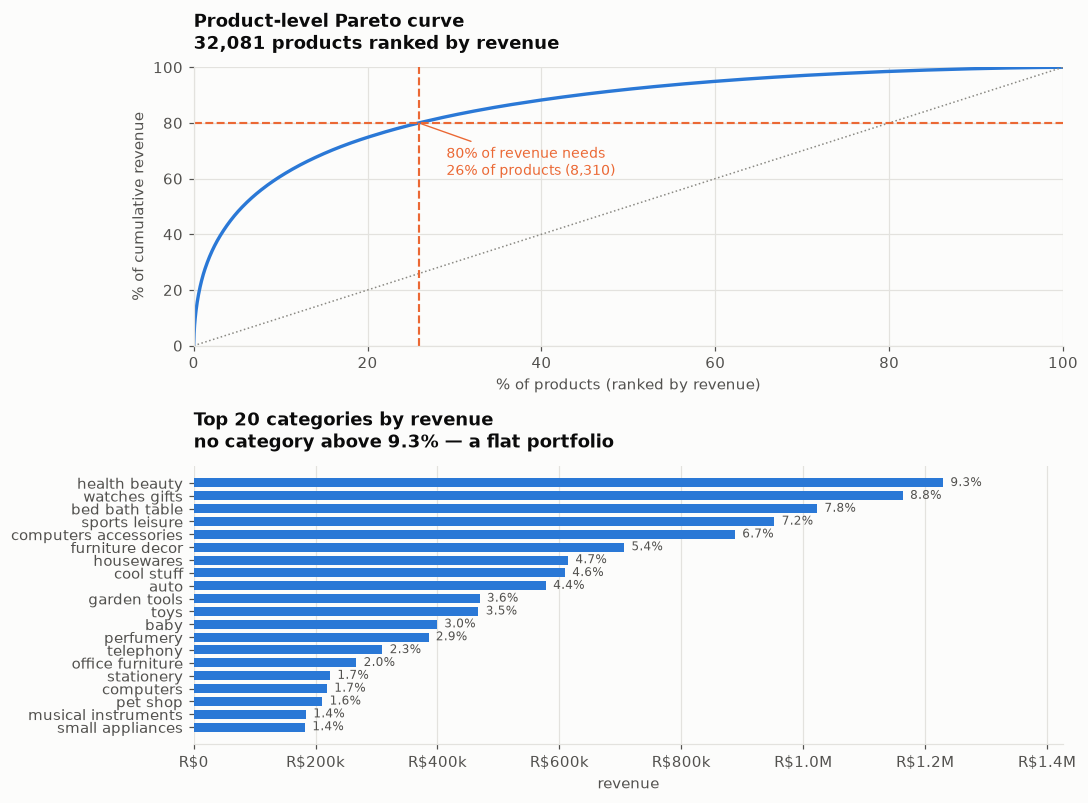

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7.4), sharex=False,
                         gridspec_kw={"height_ratios": [1, 1]})

ax = axes[0]
share = np.arange(1, len(products) + 1) / len(products) * 100
ax.plot(share, cum_rev.values, color=BLUE, linewidth=2.2)
ax.plot([0, 100], [0, 100], color=INK_3, linewidth=1, linestyle=":")
ax.axhline(80, color=ORANGE, linewidth=1.4, linestyle="--")
ax.axvline(n80 / len(products) * 100, color=ORANGE, linewidth=1.4, linestyle="--")
ax.annotate(f"80% of revenue needs\n{n80/len(products)*100:.0f}% of products ({n80:,})",
            xy=(n80/len(products)*100, 80), xytext=(18, -34),
            textcoords="offset points", fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle="-", color=ORANGE, lw=0.9))
ax.set_title("Product-level Pareto curve\n32,081 products ranked by revenue")
ax.set_xlabel("% of products (ranked by revenue)"); ax.set_ylabel("% of cumulative revenue")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
despine(ax)

ax = axes[1]
c = categories.head(20).sort_values("revenue")
ax.barh(c.index.str.replace("_", " "), c.revenue, color=BLUE, height=0.7)
for i, (v, p) in enumerate(zip(c.revenue, c.revenue_pct)):
    ax.text(v + 12000, i, f"{p:.1f}%", va="center", fontsize=8, color=INK_2)
ax.set_title("Top 20 categories by revenue\nno category above 9.3% — a flat portfolio")
ax.set_xlabel("revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.set_xlim(0, c.revenue.max() * 1.16)
ax.grid(axis="y", visible=False); despine(ax, keep=("bottom",))

plt.tight_layout(); plt.show()

**Finding — this catalogue is far less concentrated than the 80/20 rule predicts.** It takes
**25.9% of products** to reach 80% of revenue, not 20% — and at category level it takes 18 of 74.
The top 1% of products does carry 24.4% of revenue, so there *is* a head, but the tail behind it is
unusually fat.

**Strategic read:** there is no small set of hero SKUs to defend and no obvious pruning target.
Revenue resilience comes from breadth. That is characteristic of a marketplace rather than a
retailer with an owned assortment, and it argues against the usual "focus the range" reflex.

## 4. Price-vs-volume quadrant

**This replaces the conventional margin-vs-volume quadrant, which the missing cost data makes
impossible.** Categories are split against the **median category** on both axes — average selling
price and units sold — so the grid is relative to this catalogue, not to an external benchmark.

In [7]:
quad = categories[categories.units_sold >= 100].copy()
med_price = quad.avg_selling_price.median()
med_units = quad.units_sold.median()

def classify(row):
    premium = row.avg_selling_price >= med_price
    high_vol = row.units_sold >= med_units
    if premium and high_vol:
        return "Premium + high volume"
    if premium and not high_vol:
        return "Premium + low volume"
    if not premium and high_vol:
        return "Budget + high volume"
    return "Budget + low volume"

quad["quadrant"] = quad.apply(classify, axis=1)
print(f"median category selling price: R$ {med_price:,.2f}")
print(f"median category units sold   : {med_units:,.0f}")

summary = quad.groupby("quadrant").agg(
    categories=("revenue", "size"), revenue=("revenue", "sum"),
    units=("units_sold", "sum"), avg_price=("avg_selling_price", "mean"))
summary["revenue_pct"] = summary.revenue / quad.revenue.sum() * 100
display(summary.round(2))

for q in ["Premium + high volume", "Budget + high volume", "Premium + low volume", "Budget + low volume"]:
    members = quad[quad.quadrant == q].nlargest(5, "revenue").index.tolist()
    print(f"\n{q}:")
    print("   " + ", ".join(members))

median category selling price: R$ 118.35
median category units sold   : 566


,categories,revenue,units,avg_price,revenue_pct
quadrant,,,,,
Budget + high volume,15,"6,803,862.42",69250,97.50,52.03
Budget + low volume,12,"253,862.85",3308,78.45,1.94
Premium + high volume,12,"5,119,595.46",32733,170.24,39.15
Premium + low volume,15,"900,576.01",3873,255.99,6.89



Premium + high volume:
   health_beauty, watches_gifts, cool_stuff, auto, baby

Budget + high volume:
   bed_bath_table, sports_leisure, computers_accessories, furniture_decor, housewares

Premium + low volume:
   computers, home_appliances_2, agro_industry_and_commerce, furniture_living_room, home_confort

Budget + low volume:
   books_general_interest, food, market_place, costruction_tools_garden, fashion_shoes


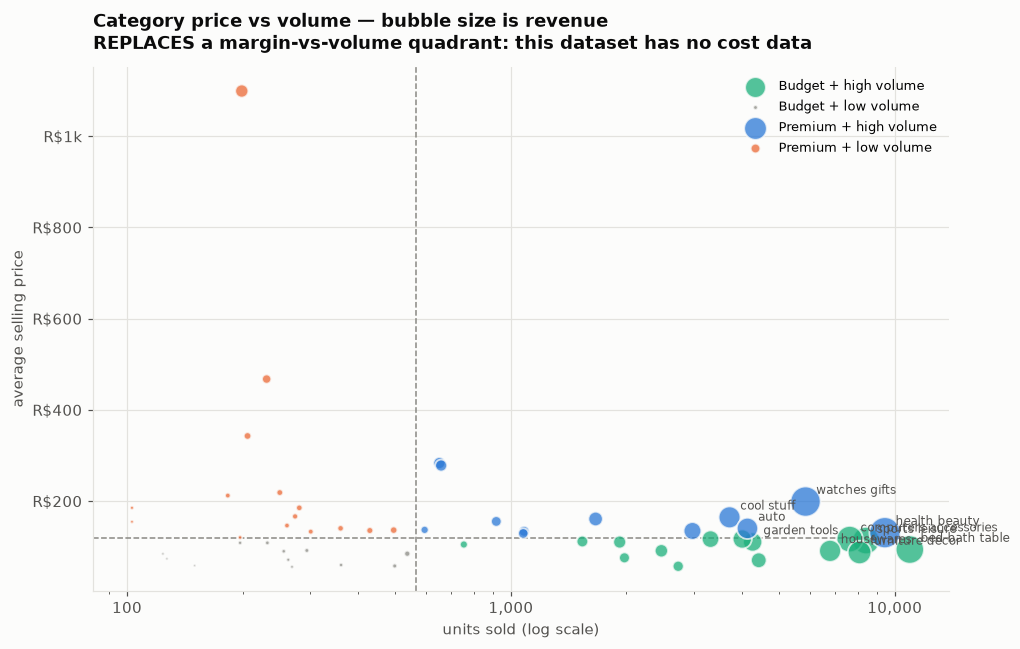

In [8]:
fig, ax = plt.subplots(figsize=(9.4, 6))

colours = {"Premium + high volume": BLUE, "Budget + high volume": AQUA,
           "Premium + low volume": ORANGE, "Budget + low volume": INK_3}
for q, grp in quad.groupby("quadrant"):
    ax.scatter(grp.units_sold, grp.avg_selling_price, s=grp.revenue / 3000,
               color=colours[q], alpha=0.75, edgecolor=SURFACE, linewidth=1.2,
               label=q, zorder=3)

ax.axvline(med_units, color=INK_3, linewidth=1, linestyle="--")
ax.axhline(med_price, color=INK_3, linewidth=1, linestyle="--")
ax.set_xscale("log")

for name in quad.nlargest(10, "revenue").index:
    row = quad.loc[name]
    ax.annotate(name.replace("_", " "), xy=(row.units_sold, row.avg_selling_price),
                xytext=(7, 5), textcoords="offset points", fontsize=8, color=INK_2)

ax.set_title("Category price vs volume — bubble size is revenue\n"
             "REPLACES a margin-vs-volume quadrant: this dataset has no cost data")
ax.set_xlabel("units sold (log scale)"); ax.set_ylabel("average selling price")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="upper right", fontsize=8.5)
despine(ax)
plt.tight_layout(); plt.show()

**How to read this without over-claiming.** The quadrant says where a category sits on *price* and
*volume* — not whether it makes money. `watches_gifts` sits high-price/high-volume and earns R$1.16M;
whether that is better business than `bed_bath_table`'s low-price/high-volume R$1.02M depends
entirely on costs this dataset does not contain.

What it *does* support: **premium + high volume categories are the ones where a marketing push has
the largest revenue effect per incremental order**, because each order is worth more. That is a
revenue argument and it stands on its own.

## 5. Category momentum — what is growing and what is shrinking

The 2018 revenue stall found in notebook 03 was an aggregate. This decomposes it: the last three
months of the window (Jun–Aug 2018) against the three before (Mar–May 2018).

In [9]:
recent = items[items.order_month.isin(["2018-06", "2018-07", "2018-08"])]
prior = items[items.order_month.isin(["2018-03", "2018-04", "2018-05"])]

momentum = pd.DataFrame({
    "revenue_mar_may": prior.groupby("product_category_name_english").revenue.sum(),
    "revenue_jun_aug": recent.groupby("product_category_name_english").revenue.sum(),
}).fillna(0)
momentum = momentum[momentum.revenue_mar_may > 20000]
momentum["change"] = momentum.revenue_jun_aug - momentum.revenue_mar_may
momentum["change_pct"] = (momentum.revenue_jun_aug / momentum.revenue_mar_may - 1) * 100
momentum = momentum.sort_values("change", ascending=False)

print("GROWING")
display(momentum.head(8).round(2))
print("DECLINING")
display(momentum.tail(8).round(2))

print(f"\ncategories analysed          : {len(momentum)}")
print(f"growing                      : {int((momentum.change > 0).sum())}")
print(f"declining                    : {int((momentum.change < 0).sum())}")
print(f"net change across categories : R$ {momentum.change.sum():,.2f}")

GROWING


,revenue_mar_may,revenue_jun_aug,change,change_pct
product_category_name_english,,,,
health_beauty,"270,081.40","329,660.95","59,579.55",22.06
housewares,"142,239.98","177,259.27","35,019.29",24.62
telephony,"60,015.77","85,735.45","25,719.68",42.85
pet_shop,"43,391.64","63,443.70","20,052.06",46.21
construction_tools_construction,"43,129.01","61,102.35","17,973.34",41.67
computers,"22,474.84","33,077.50","10,602.66",47.18
perfumery,"61,994.99","72,449.64","10,454.65",16.86
stationery,"37,180.58","45,521.92","8,341.34",22.43


DECLINING


,revenue_mar_may,revenue_jun_aug,change,change_pct
product_category_name_english,,,,
furniture_decor,"161,244.04","128,604.36","-32,639.68",-20.24
garden_tools,"99,000.71","59,903.30","-39,097.41",-39.49
office_furniture,"71,695.31","32,109.73","-39,585.58",-55.21
cool_stuff,"102,765.77","56,263.27","-46,502.50",-45.25
baby,"121,273.62","73,651.01","-47,622.61",-39.27
watches_gifts,"303,649.23","249,959.42","-53,689.81",-17.68
sports_leisure,"206,660.40","149,792.08","-56,868.32",-27.52
computers_accessories,"192,711.12","122,922.32","-69,788.80",-36.21



categories analysed          : 31
growing                      : 9
declining                    : 22
net change across categories : R$ -369,053.85


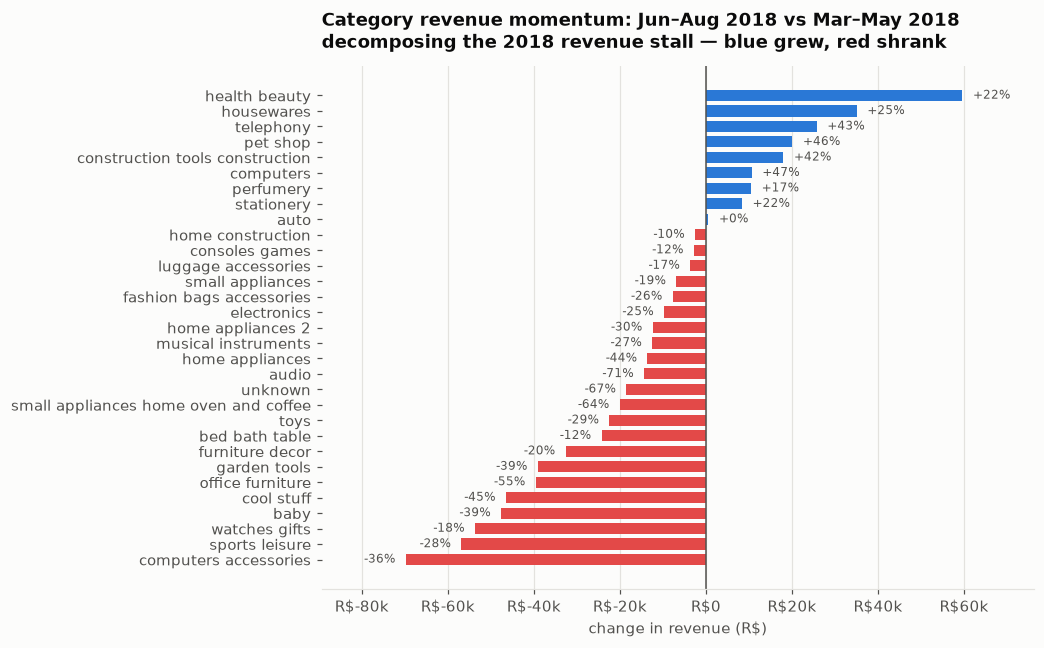

In [10]:
fig, ax = plt.subplots(figsize=(9.6, 6))
m = momentum.sort_values("change")
colors = [POS if v >= 0 else NEG for v in m.change]
ax.barh(m.index.str.replace("_", " "), m.change, color=colors, height=0.72)
ax.axvline(0, color=INK_2, linewidth=1)

for i, (v, p) in enumerate(zip(m.change, m.change_pct)):
    offset = 2500 if v >= 0 else -2500
    ax.text(v + offset, i, f"{p:+.0f}%", va="center",
            ha="left" if v >= 0 else "right", fontsize=8, color=INK_2)

ax.set_title("Category revenue momentum: Jun–Aug 2018 vs Mar–May 2018\n"
             "decomposing the 2018 revenue stall — blue grew, red shrank")
ax.set_xlabel("change in revenue (R$)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.set_xlim(m.change.min() * 1.28, m.change.max() * 1.28)
ax.grid(axis="y", visible=False); despine(ax, keep=("bottom",))
plt.tight_layout(); plt.show()

**Finding — the stall is concentrated, not universal, and this is the most actionable result in the
notebook.**

**Growing (Jun–Aug vs Mar–May 2018):**

| Category | Change | % |
|---|---|---|
| health_beauty | +R$59,580 | +22.1% |
| housewares | +R$35,019 | +24.6% |
| telephony | +R$25,720 | +42.9% |
| pet_shop | +R$20,052 | +46.2% |
| construction_tools_construction | +R$17,973 | +41.7% |
| computers | +R$10,603 | +47.2% |

**Declining:**

| Category | Change | % |
|---|---|---|
| computers_accessories | −R$69,789 | −36.2% |
| sports_leisure | −R$56,868 | −27.5% |
| watches_gifts | −R$53,690 | −17.7% |
| baby | −R$47,623 | −39.3% |
| cool_stuff | −R$46,503 | −45.3% |
| office_furniture | −R$39,586 | −55.2% |

Two of the three largest categories by revenue are shrinking fast (`computers_accessories` −36%,
`watches_gifts` −18%), while the largest, `health_beauty`, is still growing +22%. The aggregate
plateau is the **net of a genuine rotation**, not a uniform slowdown.

**Caveat on the seasonal reading.** Mar–May vs Jun–Aug spans autumn into winter in Brazil, and with
only one year of history there is no prior year to separate seasonality from trend. `sports_leisure`
and `garden_tools` falling into winter is exactly what seasonality would look like. These
movements are real in the data but their *cause* is not identifiable here.

## 6. Freight as a share of price

Not a margin measure — it is a customer-facing cost, and it varies enormously by category.

In [11]:
categories["freight_pct_of_revenue"] = categories.freight / categories.revenue * 100
freight_view = categories[categories.units_sold >= 500].sort_values("freight_pct_of_revenue",
                                                                   ascending=False)
display(freight_view[["revenue", "units_sold", "avg_selling_price",
                      "freight", "freight_pct_of_revenue"]].head(10).round(2))
print("LOWEST freight burden:")
display(freight_view[["avg_selling_price", "freight_pct_of_revenue"]].tail(5).round(2))

print(f"\noverall freight as % of revenue: {items.freight.sum()/items.revenue.sum()*100:.2f}%")
print(f"correlation(avg selling price, freight % of revenue): "
      f"{freight_view.avg_selling_price.corr(freight_view.freight_pct_of_revenue):+.3f}")

,revenue,units_sold,avg_selling_price,freight,freight_pct_of_revenue
product_category_name_english,,,,,
electronics,"154,935.94",2728,56.79,"45,667.36",29.47
office_furniture,"266,853.43",1662,160.56,"66,770.38",25.02
furniture_decor,"706,237.17",8095,87.24,"167,193.40",23.67
housewares,"614,341.62",6783,90.57,"142,508.09",23.20
telephony,"309,631.94",4422,70.02,"69,236.43",22.36
luggage_accessories,"138,701.63",1077,128.79,"30,076.49",21.68
garden_tools,"469,135.40",4263,110.05,"96,545.09",20.58
stationery,"223,788.69",2466,90.75,"45,786.36",20.46
fashion_bags_accessories,"148,945.19",1976,75.38,"30,420.50",20.42


LOWEST freight burden:


,avg_selling_price,freight_pct_of_revenue
product_category_name_english,,
cool_stuff,164.15,13.34
consoles_games,133.44,13.11
musical_instruments,283.13,9.70
watches_gifts,198.71,8.43
small_appliances,277.74,8.40



overall freight as % of revenue: 16.63%
correlation(avg selling price, freight % of revenue): -0.749


**Finding.** Freight runs **16.6% of revenue** overall, but the burden falls hardest on cheap, bulky
categories — where shipping can approach a third of the item's value — and is negligible on
high-price items. The correlation between selling price and freight burden is r = −0.75.

Because freight is paid by the customer, a high freight ratio is a **conversion risk**, not a margin
problem: it is the part of the price that delivers no product value. Categories combining low price
with high freight are the natural candidates for free-shipping thresholds or bundling — though
whether that is affordable cannot be judged without cost data.

## 7. Save product outputs

In [12]:
products.reset_index().to_parquet(PROC / "product_performance.parquet", index=False)

cat_out = categories.copy()
cat_out["quadrant"] = quad.quadrant
cat_out["revenue_mar_may_2018"] = momentum.revenue_mar_may
cat_out["revenue_jun_aug_2018"] = momentum.revenue_jun_aug
cat_out["momentum_change"] = momentum.change
cat_out["momentum_pct"] = momentum.change_pct
cat_out.reset_index().to_parquet(PROC / "category_performance.parquet", index=False)

print(f"saved product_performance.parquet  : {len(products):,} rows")
print(f"saved category_performance.parquet : {len(cat_out):,} rows")
display(cat_out.head(3).round(2))

saved product_performance.parquet  : 32,081 rows
saved category_performance.parquet : 74 rows


,revenue,units_sold,orders,products,avg_selling_price,median_price,freight,revenue_pct,cum_pct,freight_pct_of_revenue,quadrant,revenue_mar_may_2018,revenue_jun_aug_2018,momentum_change,momentum_pct
product_category_name_english,,,,,,,,,,,,,,,
health_beauty,"1,229,557.50",9422,8610,2380,130.50,79.90,"178,202.28",9.33,9.33,14.49,Premium + high volume,"270,081.40","329,660.95","59,579.55",22.06
watches_gifts,"1,163,465.91",5855,5491,1297,198.71,128.90,"98,073.50",8.83,18.16,8.43,Premium + high volume,"303,649.23","249,959.42","-53,689.81",-17.68
bed_bath_table,"1,022,955.77",10945,9267,2987,93.46,79.57,"201,646.91",7.76,25.92,19.71,Budget + high volume,"210,431.03","186,153.40","-24,277.63",-11.54


## 8. Findings

### Concentration
1. **This catalogue is not 80/20 — it is 80/26.** 8,310 of 32,081 products (25.9%) are needed to
   reach 80% of revenue; 18 of 74 categories.
2. **No product or category dominates.** The largest product is 0.48% of revenue, the top 10
   products under 3.3%, and the largest category 9.3%.
3. **The long tail is substantial**: 55.0% of products sold exactly once, yet they carry **21.5% of
   revenue** at an above-average selling price.

### Structure
4. **Two distinct routes to high revenue** — high volume at R$70–90, or 30–40 units at
   R$1,000–1,400. A units-based bestseller ranking would miss half the top performers.
5. **Freight is 16.6% of revenue** and falls hardest on cheap, bulky goods — a conversion risk
   rather than a margin issue.

### Momentum
6. **The 2018 stall is a rotation, not a uniform decline.** `health_beauty` (+22%), `housewares`
   (+25%), `telephony` (+43%) and `pet_shop` (+46%) grew, while `computers_accessories` (−36%),
   `baby` (−39%), `cool_stuff` (−45%) and `office_furniture` (−55%) fell.
7. **Seasonality cannot be ruled out** — Mar–May vs Jun–Aug crosses into Brazilian winter and there
   is no prior year to compare against.

### What the data cannot answer
8. **No profitability analysis is possible** — no COGS, commission or fulfilment cost exists. The
   margin-vs-volume quadrant was replaced with price-vs-volume, and "worst performer" means
   "sells little", never "loses money".
9. **The single highest-value question new data could unlock** is whether the 55% one-sale tail is
   profitable breadth or dead weight. That needs a cost field; it cannot be inferred.

---
**Next:** Phase 10 — Marketing Analytics using available proxies (`08_marketing_analysis.ipynb`).